# Finsler Flow Matching on the mouse erythroid lineage

In [1]:
%matplotlib inline

import matplotlib
_NB_BACKEND = matplotlib.get_backend()

import os
import pathlib
import sys

_here = pathlib.Path.cwd().resolve()
PUBLIC = next((p for p in (_here, *_here.parents)
               if (p / "scripts").is_dir() and (p / "notebooks").is_dir()), None)
assert PUBLIC is not None, "run this from inside the repo's public/ tree"
sys.path.insert(0, str(PUBLIC))

import json

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
from IPython.display import Image, Markdown, display

from scripts.experiments.erythroid.datasets import (CACHE_DIR, DIMS, HOLDOUT_BIN,
                                                    HOLDOUT_VAL_FRACTION, TRAIN_BINS,
                                                    build_training_set, load_cloud,
                                                    split_holdout, split_shown)
from scripts.experiments.erythroid.reference_release import REFERENCE_K
from scripts.experiments.erythroid.train import (ARM_BLOCK, ARM_LABELS, ARMS,
                                                 INHERIT, N_STEPS_ERYTHROID, PINNED,
                                                 SEEDS, SPLIT_SEED, VAL_FRACTION,
                                                 anchor_point, stage_test)
from scripts.core import sensitivity as sens
from scripts.core.paths import experiment_root, figure_dir, rel, table_file
from scripts.experiments.erythroid import figures as efig
from scripts.experiments.erythroid import report as erep
from scripts.method import (Run, TableStore, moments_from, pct_change,
                            results_table, rho_star, seed_frame, table_summary,
                            table_walltime)

matplotlib.use(_NB_BACKEND)
import matplotlib.pyplot as plt

pd.set_option("display.width", 220)
print(f"torch {torch.__version__}   cuda {torch.cuda.is_available()}")
print(f"cache  {rel(CACHE_DIR)}")
assert os.path.isdir(CACHE_DIR), (
    f"no UniTVelo cache at {CACHE_DIR}; step 0 runs in its own conda env:\n"
    f"    python -m scripts.experiments.erythroid.preprocess\n"
    f"or point ERYTHROID_CACHE at an existing one.")

torch 2.4.0+cu124   cuda True
cache  data/erythroid_cache


## Data

In [2]:
cfg = Run.from_env()

DIMS_RUN = tuple(int(d) for d in os.environ["NB_DIMS"].split(",")) if os.environ.get(
    "NB_DIMS") else DIMS
assert set(DIMS_RUN) <= set(DIMS), f"NB_DIMS must be a subset of {DIMS}"
REPORTED_SEEDS = (0,) if cfg.smoke else SEEDS
ARMS_RUN = ARMS
ROOT = experiment_root("erythroid_bench", smoke=cfg.smoke)

TUNED = {
    2: {
        'cfm': {'blur_frac': 3.000000e+01},
        'mfm_land': {'land_gamma': 4.000000e-02},
        'curly': {'curly_alpha': 1.000000e-01},
        'ffm': {'rho_mult': 3.000000e-04, 'lam_mult': 1.000000e+01},
        'pathb': {'width_mult': 3.000000e-03},
        'cfm_release': {},
        'curly_release': {},
    },
    20: {
        'cfm': {'blur_frac': 1.000000e+01},
        'mfm_land': {'land_rho': 3.000000e-01},
        'curly': {'curly_alpha': 1.000000e+04},
        'ffm': {'rho_mult': 3.000000e-04, 'lam_mult': 3.000000e+01},
        'pathb': {'width_mult': 1.000000e-01},
        'cfm_release': {},
        'curly_release': {},
    },
    50: {
        'cfm': {'blur_frac': 1.000000e-02},
        'mfm_land': {'land_rho': 1.000000e-02},
        'curly': {'curly_alpha': 1.000000e+04},
        'ffm': {'rho_mult': 1.000000e-03, 'lam_mult': 1.000000e+01},
        'pathb': {'width_mult': 1.000000e-01},
        'cfm_release': {},
        'curly_release': {},
    },
}

_tuned_file = PUBLIC / "scripts/experiments/erythroid/tuned.json"
TUNED_IS_SEARCHED = bool(TUNED)
if _tuned_file.exists():
    _saved = {int(d): a for d, a in json.loads(_tuned_file.read_text()).items()}
    assert TUNED == _saved, ("TUNED is stale -- re-run `python -m "
                             "scripts.experiments.erythroid.tune collect` and paste the "
                             "literal it prints.")
elif TUNED:
    raise AssertionError("TUNED is pasted with no tuned.json to check it against; "
                         "re-run `tune collect`.")
else:
    TUNED = {d: {a: ({} if a in PINNED else anchor_point(a, d)) for a in ARMS_RUN}
             for d in DIMS_RUN}
    for _d in DIMS_RUN:
        for _a, _src in INHERIT.items():
            if _a in TUNED[_d] and _src in TUNED[_d]:
                TUNED[_d][_a] = TUNED[_d][_src]
PICKS = {(d, a): TUNED[d][a] for d in DIMS_RUN for a in ARMS_RUN}
for _d in DIMS_RUN:
    assert set(ARMS_RUN) <= set(TUNED[_d]), \
        f"d={_d} is missing {sorted(set(ARMS_RUN) - set(TUNED[_d]))}"


clouds, tsets = {}, {}
for dim in DIMS_RUN:
    cloud = load_cloud(dim)
    i_train, i_val = split_shown(cloud, VAL_FRACTION, SPLIT_SEED)
    i_sel, i_test = split_holdout(cloud)
    ts = build_training_set(cloud)
    clouds[dim], tsets[dim] = cloud, ts

    assert len(set(i_sel) & set(i_test)) == 0, "selection slice and scored slice overlap"
    assert len(i_sel) + len(i_test) == int((cloud.bin_id == HOLDOUT_BIN).sum()), \
        "the holdout does not partition the withheld marginal"
    assert not np.isin(ts.idx, cloud.marginal(HOLDOUT_BIN)).any(), \
        "a withheld cell reached the training set"

    P = sp.csr_matrix(ts.P)
    b0, D = moments_from(P, np.asarray(ts.X, dtype=np.float64))
    nb0 = np.linalg.norm(b0, axis=1)
    

edges = clouds[DIMS_RUN[0]].diag["quantile_edges"]

TBL = TableStore.open(
    table_file("erythroid", cfg.smoke), benchmark="erythroid", smoke=cfg.smoke,
    seeds=list(REPORTED_SEEDS), arms=list(ARMS_RUN), n_steps=N_STEPS_ERYTHROID,
    device="CPU" if cfg.device.type == "cpu" else torch.cuda.get_device_name(0))
TBL.put_tuned(TUNED)
TBL.save()

## How many dimensions the cloud actually has

Local intrinsic dimension around individual cells, in the ambient gene space and in each
PCA prefix, by four estimators that fail differently: two Poisson-process MLEs on neighbour
distances, a tail estimate over all pairs, and a spectral count that models no manifold at
all. Same sampled cells and same $k$ in every row. All four are biased downwards, so the
reading is across representations at a fixed estimator. The participation ratio cannot
exceed $k$; the last table doubles $k$ to say which rows are pinned against that.

In [3]:
from scripts.core import intrinsic_dim as idim
from scripts.experiments.erythroid.ambient import load_ambient

ID_K = idim.K_NEIGHBOURS

_X50 = np.asarray(load_cloud(50).X, dtype=np.float64)
_amb, _amb_info = load_ambient(check_against=load_cloud(50).celltype)

ID_REPS = {}
if _amb is not None:
    assert len(_amb) == len(_X50), "gene matrix and PCA cache disagree on the cell count"
    ID_REPS[f"ambient ({_amb.shape[1]} genes)"] = _amb
ID_REPS.update({"PCA 10": _X50[:, :10], "PCA 20": _X50[:, :20], "PCA 50": _X50[:, :50]})

ID_CELLS = idim.sample_cells(len(_X50))
ID_LOC = {name: idim.prepare(name, X, ID_CELLS, k=ID_K) for name, X in ID_REPS.items()}

ID_TWONN = {n: idim.twonn_local(loc) for n, loc in ID_LOC.items()}
ID_MLE = {n: idim.knn_mle(loc) for n, loc in ID_LOC.items()}
ID_TLE = {n: idim.tle(loc) for n, loc in ID_LOC.items()}
ID_PR, _n95 = {}, {}
for _n, _loc in ID_LOC.items():
    ID_PR[_n], _nl = idim.lpca_pr(_loc)
    _n95[_n] = {"n95 mean": float(_nl.mean()), "n95 med": float(np.median(_nl))}

_loc2 = {n: idim.prepare(n, X, ID_CELLS, k=2 * ID_K) for n, X in ID_REPS.items()}
_pr1 = {n: float(np.nanmean(v)) for n, v in ID_PR.items()}
_pr2 = {n: float(np.nanmean(idim.lpca_pr(l)[0])) for n, l in _loc2.items()}

display(Markdown(f"**TwoNN** (k = {ID_K})"))
display(idim.summarise(ID_TWONN, ID_LOC).round(2))
display(Markdown(f"**kNN-MLE (Levina–Bickel)** (k = {ID_K})"))
display(idim.summarise(ID_MLE, ID_LOC).round(2))
display(Markdown(f"**TLE** (k = {ID_K})"))
display(idim.summarise(ID_TLE, ID_LOC).round(2))
display(Markdown(f"**Local PCA participation ratio** (k = {ID_K})"))
display(idim.summarise(ID_PR, ID_LOC, extra=_n95).round(2))
display(Markdown("**Participation ratio vs neighbourhood size**"))
display(pd.DataFrame({f"PR at k={ID_K}": _pr1,
                      f"PR at k={2 * ID_K}": _pr2,
                      "ratio": {n: _pr2[n] / _pr1[n] for n in _pr1},
                      "reading": {n: ("pinned to k, so read it as >= k"
                                      if _pr2[n] > 1.25 * _pr1[n] else "stable in k")
                                  for n in _pr1}}).round(2))

**TwoNN** (k = 50)

,ambient d,cells,k,mean,median,sd,p10,p90,dropped,dup cells
PCA 10,10.0,1500.0,50.0,8.70,8.64,1.37,7.07,10.44,0.0,0.0
PCA 20,20.0,1500.0,50.0,13.10,12.96,2.28,10.29,16.04,0.0,0.0
PCA 50,50.0,1500.0,50.0,22.72,22.49,4.15,17.53,28.07,0.0,0.0


**kNN-MLE (Levina–Bickel)** (k = 50)

,ambient d,cells,k,mean,median,sd,p10,p90,dropped,dup cells
PCA 10,10.0,1500.0,50.0,6.91,6.77,1.48,5.20,8.79,0.0,0.0
PCA 20,20.0,1500.0,50.0,10.27,10.13,2.38,7.50,13.27,0.0,0.0
PCA 50,50.0,1500.0,50.0,17.26,17.05,4.35,12.09,22.54,0.0,0.0


**TLE** (k = 50)

,ambient d,cells,k,mean,median,sd,p10,p90,dropped,dup cells
PCA 10,10.0,1500.0,50.0,6.81,6.76,1.17,5.40,8.34,0.0,0.0
PCA 20,20.0,1500.0,50.0,9.73,9.71,1.85,7.46,12.02,0.0,0.0
PCA 50,50.0,1500.0,50.0,15.22,15.17,3.20,11.33,19.20,0.0,0.0


**Local PCA participation ratio** (k = 50)

,ambient d,cells,k,mean,median,sd,p10,p90,dropped,dup cells,n95 mean,n95 med
PCA 10,10.0,1500.0,50.0,6.64,6.72,0.74,5.70,7.50,0.0,0.0,8.62,9.0
PCA 20,20.0,1500.0,50.0,10.40,10.58,1.29,8.62,11.90,0.0,0.0,15.00,15.0
PCA 50,50.0,1500.0,50.0,18.08,18.49,2.44,14.84,20.79,0.0,0.0,28.40,29.0


**Participation ratio vs neighbourhood size**

,PR at k=50,PR at k=100,ratio,reading
PCA 10,6.64,6.74,1.01,stable in k
PCA 20,10.40,11.05,1.06,stable in k
PCA 50,18.08,20.88,1.16,stable in k


## What the model is given

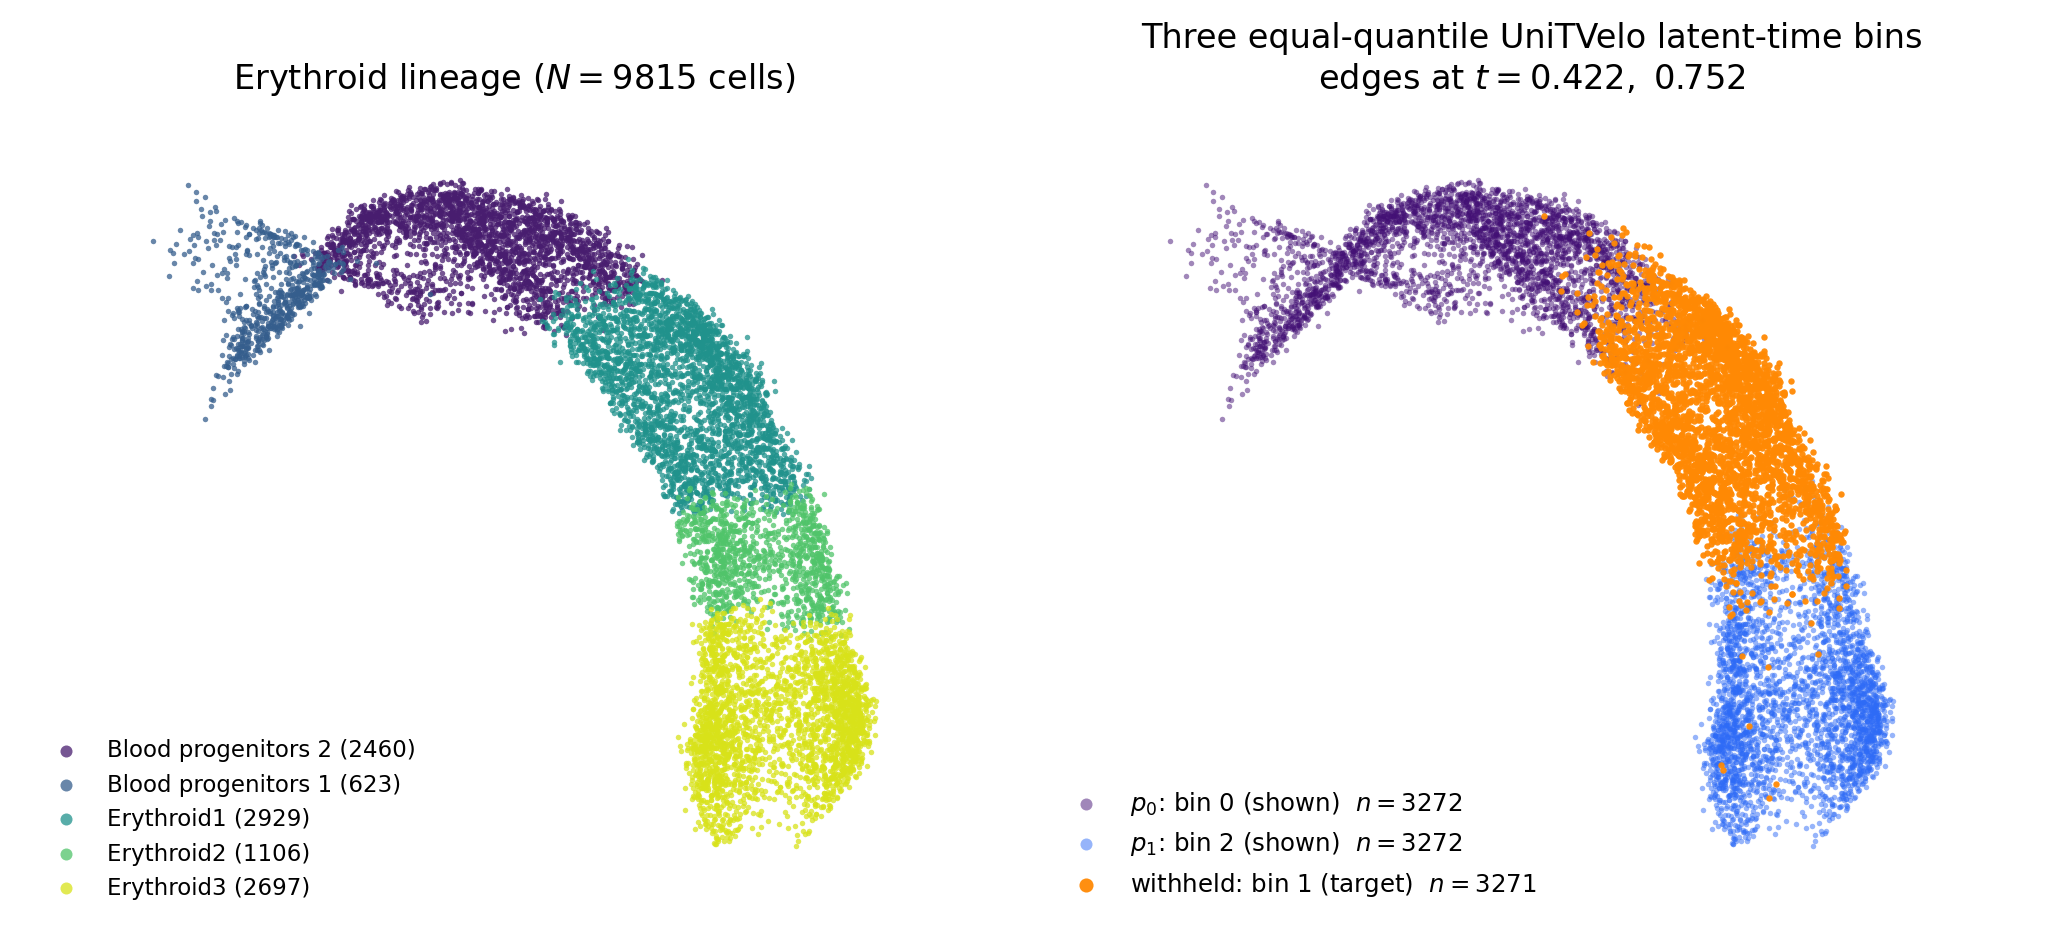

In [4]:
_out = pathlib.Path(figure_dir(cfg.smoke))
_out.mkdir(exist_ok=True)
display(Image(filename=f"{efig.figure_data(clouds[DIMS_RUN[0]], str(_out))}.png"))

## runs

In [5]:
stage_test(str(ROOT), PICKS, DIMS_RUN, ARMS_RUN, REPORTED_SEEDS,
           cfg.device, cfg.dtype, N_STEPS_ERYTHROID, cfg.smoke, force=False)

_got = erep.collect(str(ROOT), DIMS_RUN, ARMS_RUN)
for (_d, _a), _recs in _got.items():
    for _r in _recs:
        TBL.put_run(_d, _a, _r["seed"], _r["metrics"], _r.get("train_seconds"))
TBL.save()
print(f"stored {sum(len(TBL.times(_d)) for _d in DIMS_RUN)} runs -> {rel(TBL.path)}")

[test] skip d2_cfm_release_s0.json
[test] skip d2_cfm_release_s1.json
[test] skip d2_cfm_release_s2.json
[test] skip d2_cfm_release_s3.json
[test] skip d2_cfm_release_s4.json
[test] skip d2_curly_release_s0.json
[test] skip d2_curly_release_s1.json
[test] skip d2_curly_release_s2.json
[test] skip d2_curly_release_s3.json
[test] skip d2_curly_release_s4.json
[test] skip d2_cfm_s0.json
[test] skip d2_cfm_s1.json
[test] skip d2_cfm_s2.json
[test] skip d2_cfm_s3.json
[test] skip d2_cfm_s4.json
[test] skip d2_mfm_land_s0.json
[test] skip d2_mfm_land_s1.json
[test] skip d2_mfm_land_s2.json
[test] skip d2_mfm_land_s3.json
[test] skip d2_mfm_land_s4.json
[test] skip d2_curly_s0.json
[test] skip d2_curly_s1.json
[test] skip d2_curly_s2.json
[test] skip d2_curly_s3.json
[test] skip d2_curly_s4.json
[test] skip d2_ffm_s0.json
[test] skip d2_ffm_s1.json
[test] skip d2_ffm_s2.json
[test] skip d2_ffm_s3.json
[test] skip d2_ffm_s4.json
[test] skip d2_pathb_s0.json
[test] skip d2_pathb_s1.json
[test] 

## Table

In [6]:
print(erep.table_e1(str(ROOT), DIMS_RUN, ARMS_RUN))

COLUMNS = {erep.METRIC_LABELS[_m]: (_m,) for _m in erep.METRICS}
REL_COL, REL_KEY = 'W2 (true)', 'w2_true'

print(f"\n{REL_COL} per column, mean over {len(REPORTED_SEEDS)} seeds")
print(table_summary(TBL, ARMS_RUN, REPORTED_SEEDS, DIMS_RUN, REL_COL, COLUMNS
                    ).rename(index=ARM_LABELS).to_string(float_format="%.4f"))

print()
for _d in DIMS_RUN:
    _runs = TBL.runs(_d)
    _ours = [_a for _a in ARMS_RUN if ARM_BLOCK.get(_a) == "ours"]
    _base = [_a for _a in ARMS_RUN if ARM_BLOCK.get(_a) == "harness"]
    if not (_ours and _base):
        continue
    _mean = lambda a: seed_frame(_runs, a, REPORTED_SEEDS, COLUMNS)[REL_COL].mean()
    _best = min(_base, key=_mean)
    print(f"d = {_d:<3} {REL_COL:<10} best harness {ARM_LABELS[_best]:<20} " + "   ".join(
        f"{ARM_LABELS[_a]} {pct_change(_runs, _best, _a, REPORTED_SEEDS, (REL_KEY,)):+.1f}%"
        for _a in _ours))


E1  Erythroid: their Table 4 statistics, in four blocks

  d = 2                               Cos. Dist                L2   W1 (their "W2")         W2 (true)
-----------------------------------------------------------------------------------------------------
[published   Petrovic et al. (2025) Table 4 -- their code, their data, transcribed]
  OT-CFM                          0.146 ± 0.001     2.704 ± 0.019     0.646 ± 0.006                --
  MFM                             0.014 ± 0.001     1.999 ± 0.014     0.269 ± 0.004                --
  CURLY-FM                        0.009 ± 0.000     1.663 ± 0.293     0.369 ± 0.090                --
[release     their training code at their published hyper-parameters, on OUR cache]
  OT-CFM (their code)             0.147 ± 0.001     2.434 ± 0.036     0.649 ± 0.003     0.705 ± 0.003
  Curly-FM (their code)           0.012 ± 0.002     0.942 ± 0.253     0.526 ± 0.174     0.545 ± 0.167
[harness     baselines through our trainer at their publishe

## Wall Clock time

In [7]:
_t = table_walltime(TBL, ARMS_RUN, REPORTED_SEEDS, DIMS_RUN)
_dev = TBL.meta["device"]
print(f"seconds of training, mean over {len(REPORTED_SEEDS)} seed(s) -- {_dev}")
print(_t.rename(index=ARM_LABELS).to_string(float_format="%.0f"))
_total = sum(sum(TBL.times(_d).values()) for _d in DIMS_RUN)
print(f"\nwhole notebook: {_total / 60:.0f} min of training over "
      f"{sum(len(TBL.times(_d)) for _d in DIMS_RUN)} runs "
      f"({len(DIMS_RUN)} spaces x {len(ARMS_RUN)} arms x {len(REPORTED_SEEDS)} seeds)"
      + ("   [smoke budget -- not the real cost]" if cfg.smoke else ""))

seconds of training, mean over 5 seed(s) -- Tesla V100-SXM2-32GB
                           d = 2  d = 20  d = 50
OT-CFM (their code)           37      40      40
Curly-FM (their code)         98     343     777
OT-CFM (harness)               7       7      10
MFM/LAND (harness)            27     135     323
Curly-FM (harness)            57     184     411
FFM, deterministic (ours)     32     146     382
FFM, with noise (ours)        51     211     523
one seed, all arms           310    1067    2466

whole notebook: 320 min of training over 105 runs (3 spaces x 7 arms x 5 seeds)


## Hyper-parameter sensitivity

In [8]:
SENS_DIM = int(os.environ.get("NB_SENS_DIM", 20 if 20 in DIMS_RUN else DIMS_RUN[0]))
assert SENS_DIM in DIMS_RUN, f"NB_SENS_DIM={SENS_DIM} is not in DIMS_RUN={DIMS_RUN}"

_panels, _noise = erep.sensitivity_panels(str(ROOT), SENS_DIM, ARMS_RUN, TUNED[SENS_DIM])
display(sens.table(_panels, "selection objective (val W2)", noise=_noise))

selection objective (val W2)  delta % > seed
model                     knob        value                                                 
OT-CFM (harness)          blur_frac   0.3                             5.3159      0.1       
                                      1                               5.3173      0.1       
                                      3                               5.3151      0.1       
                                      10 *                            5.3101      0.0       
                                      30                              5.3150      0.1       
MFM/LAND (harness)        land_rho    0.003                           5.9114      9.3    yes
                                      0.01                            5.7764      6.8    yes
                                      0.03                            5.6360      4.2    yes
                                      0.1                             5.5177      2.0    yes
                                      0.3 *                           5.4092      0.0       
Curly-FM (harness)        curly_alpha 10                             10.8942    105.7    yes
                                      100                             5.6066      5.9    yes
                                      1000                            5.3158      0.4       
                                      1e+04 *                         5.2952      0.0       
                                      1e+05                           5.3052      0.2       
FFM, deterministic (ours) rho_mult    0.0003 *                        4.6616      0.0       
                                      0.001                           4.6622      0.0       
                                      0.003                           4.6648      0.1       
                                      0.01                            4.6662      0.1       
                                      0.03                            4.6683      0.1       
                          lam_mult    0.3                             6.0335     29.4    yes
                                      1                               5.5764     19.6    yes
                                      3                               4.9226      5.6    yes
                                      10                              4.7072      1.0       
                                      30 *                            4.6616      0.0       
FFM, with noise (ours)    width_mult  0.01                            6.2375      4.1    yes
                                      0.03                            6.1685      3.0    yes
                                      0.1 *                           5.9913      0.0       
                                      0.3                             6.1031      1.9    yes
                                      1                               7.4367     24.1    yes

## figure

$d = 2$ only: at $d = 20$ and $50$ the first two principal coordinates are not a picture
of the method, and those columns are reported in E1 and E2 instead.

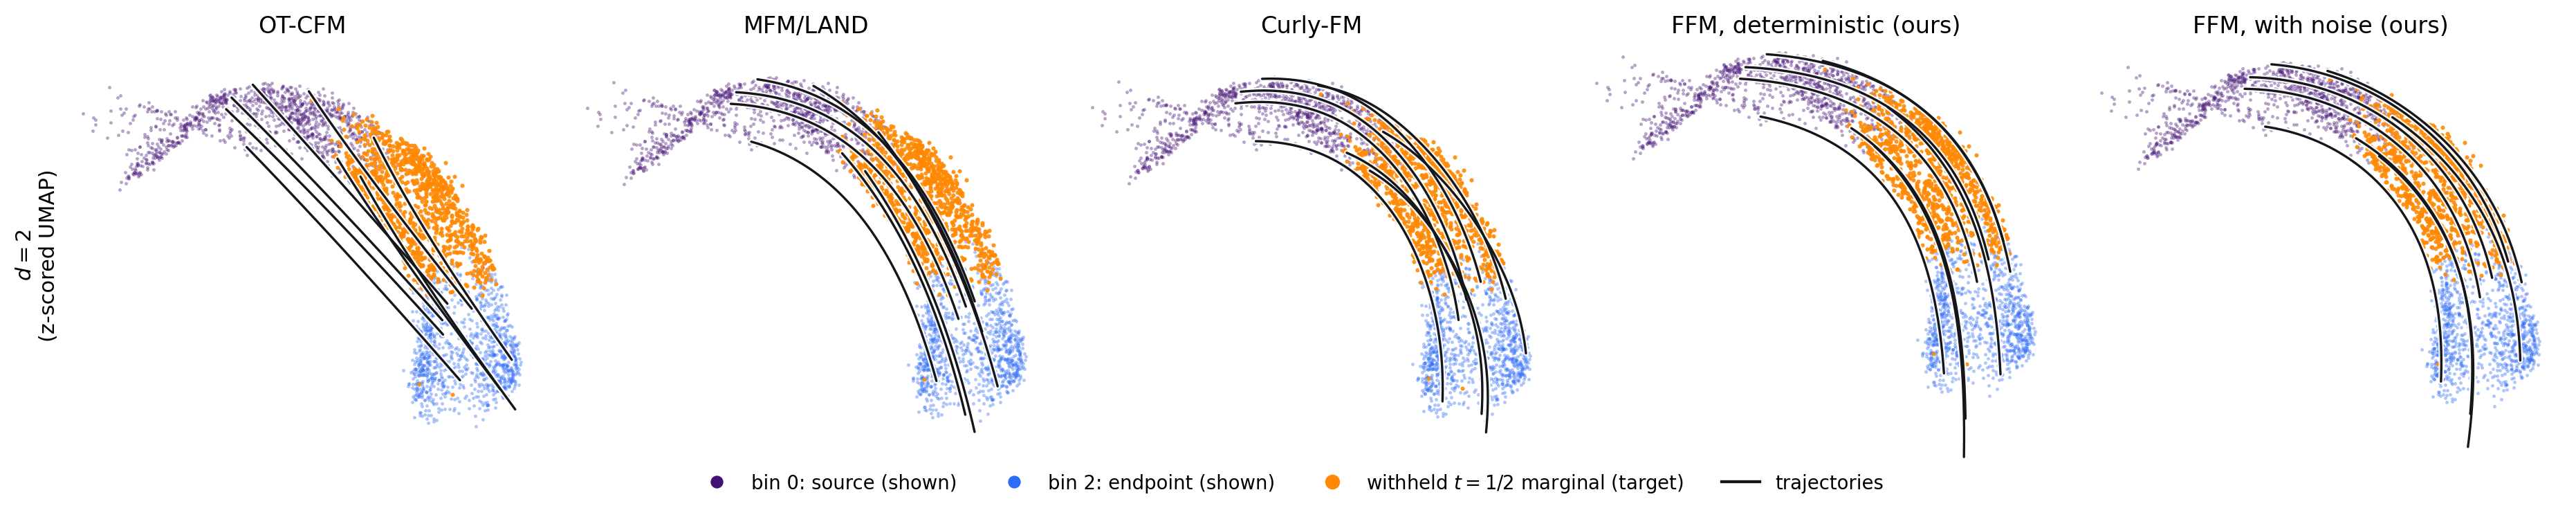

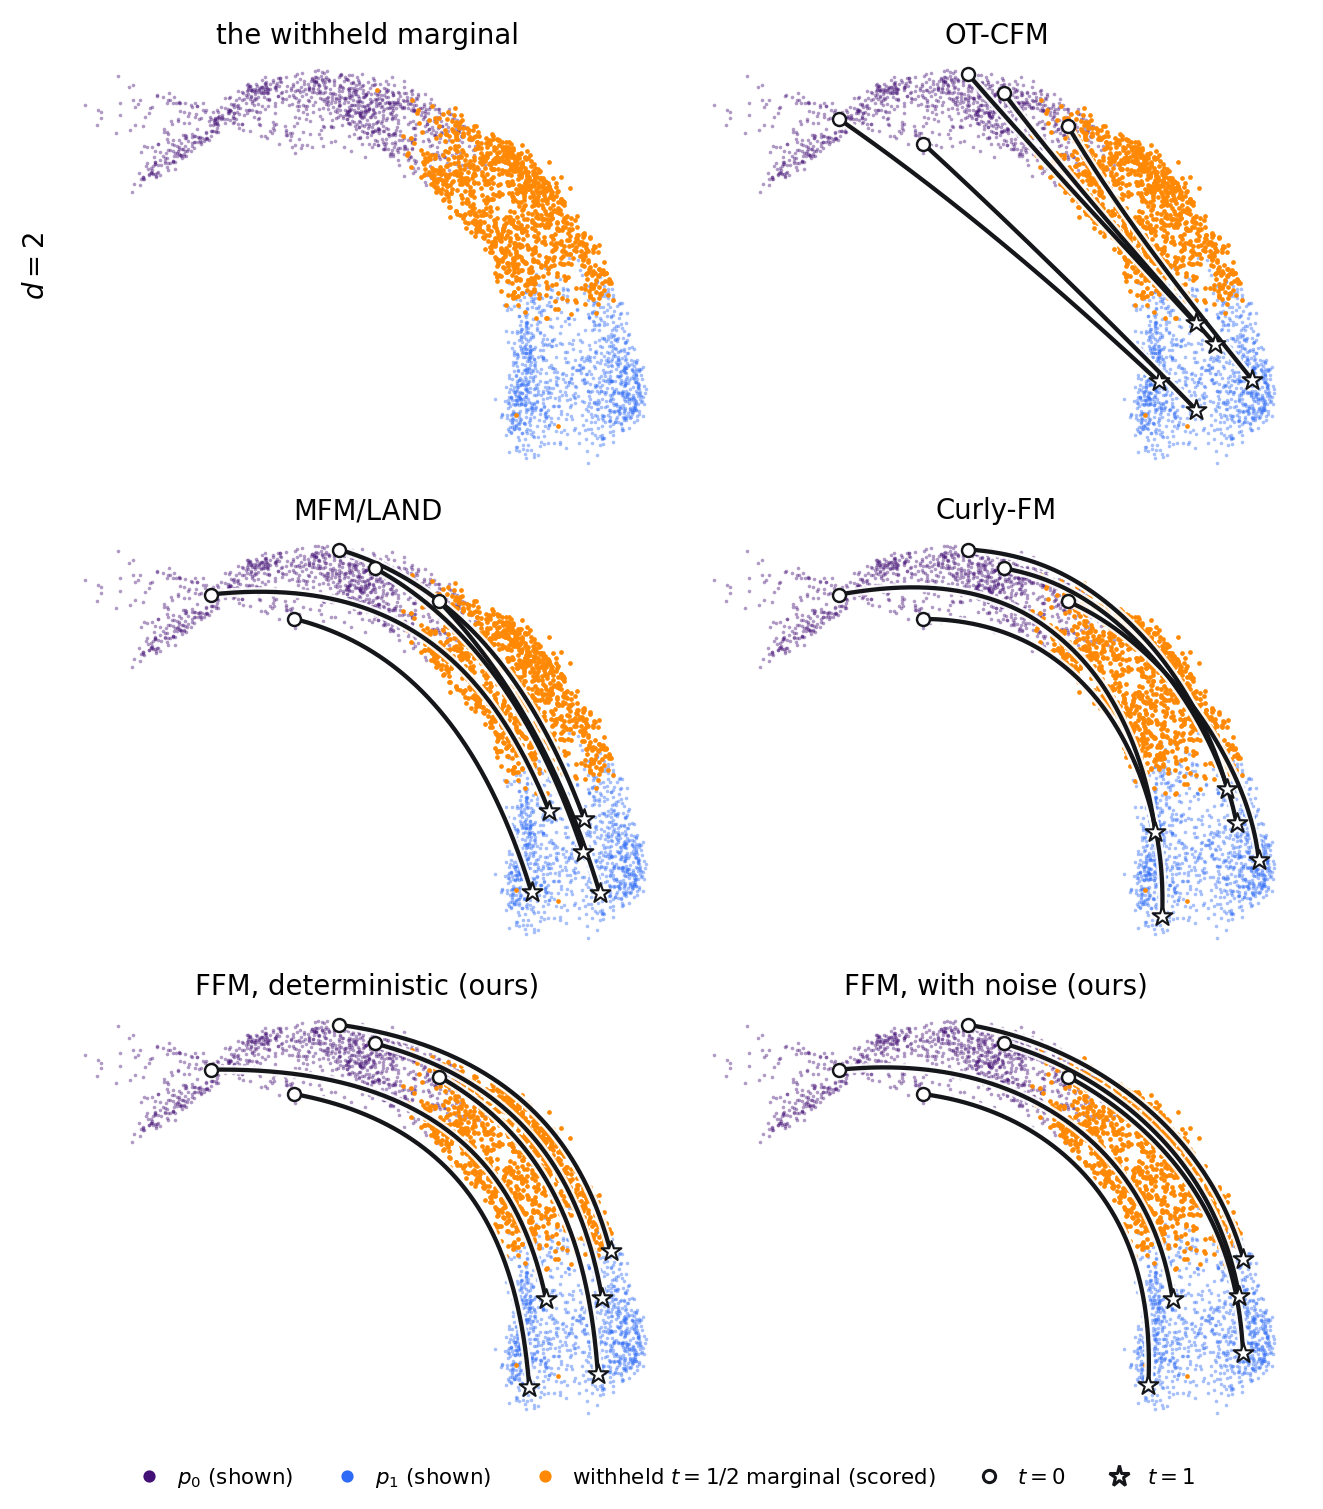

In [9]:
FIG_DIMS = tuple(d for d in DIMS_RUN if d == 2)

if not FIG_DIMS:
    print(f"no figure: d = 2 is not in DIMS_RUN = {DIMS_RUN}")
else:
    display(Image(filename=f"{efig.figure_compare(str(ROOT), FIG_DIMS, ARMS_RUN, str(_out), seed=REPORTED_SEEDS[0])}.png"))
    display(Image(filename=f"{efig.figure_paths(str(ROOT), ARMS_RUN, str(_out), seed=REPORTED_SEEDS[0])}.png"))

In [10]:
from scripts.experiments.erythroid import review as erv

EREVIEW = erv.ensure(cfg, TUNED)
for _f in erv.frames(EREVIEW):
    print(_f.round(4).to_string())
    print()

                                         n    mean      sd    q2.5   q97.5  seeds 0-4  end W2  P(FFM tuned run wins)
erythroid d = 2, W2 (paper's column)                                                                                
FFM, tuned point                      20.0  0.2874  0.0184  0.2524  0.3167     0.2793  0.2254                    NaN
FFM, default point                    20.0  0.4142  0.0373  0.3645  0.4789     0.4165  0.2142                 1.0000
OT-CFM (harness)                      20.0  0.6776  0.0101  0.6630  0.6950     0.6794  0.1736                 1.0000
MFM / LAND (harness)                  20.0  0.2851  0.0188  0.2521  0.3175     0.2856  0.2169                 0.4575
Curly-FM (harness)                    20.0  0.1524  0.0062  0.1431  0.1639     0.1577  0.1376                 0.0000

                                    seeds      W2  chaos %  within / seed sd
erythroid d = 2, 1e-7 perturbation                                          
FFM, tuned point          